# Notebook 00 — Base compartida del proyecto
**CCPG1044 Inteligencia Artificial — Grupo N.° 4**
Clasificación de cuentas de Instagram (auténticas / falsas)

Este notebook es el **único** punto donde se cargan, limpian, exploran y particionan los datos.
Los cinco modelos del proyecto se entrenan en notebooks separados, pero **todos** parten de la
partición generada aquí y guardada en Drive. Esto es lo que hace válida la comparación final
entre los cinco algoritmos.

**Ejecutar una sola vez.** Después de correrlo, cada integrante solo carga los archivos `.npz`/`.joblib`
desde la carpeta compartida.

---
Orden de ejecución del proyecto:

| Notebook | Responsable | Contenido |
|---|---|---|
| `00_base_compartida` | Persona A | Carga, EDA, limpieza, partición y escalado |
| `01_regresion_logistica_arbol` | Persona A | Regresión Logística + Árbol de Decisión |
| `02_random_forest_gradient_boosting` | Persona B | Random Forest + Gradient Boosting |
| `03_red_neuronal_mlp` | Persona C | MLP entrenado desde cero |
| `04_comparacion_final` | Persona B | Métricas, curvas ROC e importancia de variables de los 5 modelos |
| `05_interfaz` | Persona C | Interfaz para clasificar una cuenta nueva |


## 1. Configuración del entorno y rutas compartidas

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

SEMILLA = 42          # reproducibilidad: misma particion para los cinco modelos
np.random.seed(SEMILLA)
print('Librerias cargadas.')

Librerias cargadas.


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# --- AJUSTAR ESTA RUTA A LA CARPETA COMPARTIDA DEL GRUPO ---
if IN_COLAB:
    CARPETA = '/content/drive/MyDrive/Proyecto_IA_Grupo4'
else:
    # Ejecutando localmente: ajuste esta ruta a la carpeta compartida del grupo
    # Ejemplo Windows: 'C:/Users/<tu_usuario>/Drive/Proyecto_IA_Grupo4'
    CARPETA = os.path.expanduser(r'c:/Users/JDC/Universidad/File_General/NIVEL_400-I/Proy_IA_G4')
RUTA_CSV = f'{CARPETA}/user_fake_authentic_2class.csv'
RUTA_SPLIT = f'{CARPETA}/split'          # aqui se guarda la particion compartida
RUTA_FIGS = f'{CARPETA}/figuras'         # graficos para el informe

os.makedirs(RUTA_SPLIT, exist_ok=True)
os.makedirs(RUTA_FIGS, exist_ok=True)
print('Carpeta de trabajo:', CARPETA, '| In Colab:', IN_COLAB)

# Intentar asegurar que los CSVs necesarios existen; si faltan, descargarlos desde Drive con gdown
needed_files = ['user_fake_authentic_2class.csv', 'user_fake_authentic_4class.csv']
missing = [f for f in needed_files if not os.path.exists(os.path.join(CARPETA, f))]
if missing:
    print('Faltan archivos en', CARPETA, '->', missing)
    if not IN_COLAB:
        try:
            import subprocess, sys
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
            import gdown

            # URL de la carpeta compartida en Drive (debe estar como "Cualquiera con el enlace")
            FOLDER_URL = 'https://drive.google.com/drive/folders/1ixCh1KRYp3eX2erUMzVFp3tOD5fkyJ5c?usp=drive_link'
            gdown.download_folder(url=FOLDER_URL, output=CARPETA, quiet=False, use_cookies=False)

            # recomponer lista de faltantes
            missing = [f for f in needed_files if not os.path.exists(os.path.join(CARPETA, f))]
            if missing:
                print('Quedan archivos faltantes tras la descarga:', missing)
            else:
                print('Archivos descargados correctamente desde Drive.')
        except Exception as e:
            print('No fue posible descargar automáticamente desde Drive:', e)
            print('Opciones: verificar que la carpeta esté compartida como "Cualquiera con el enlace",',
                  'sincronizarla con Google Drive for Desktop, o descargar manualmente los archivos')
    else:
        print('En Colab el folder está montado; verifique que los archivos existan en la carpeta compartida en Drive')

## 2. Carga y verificación de integridad

Antes de tocar los datos se verifica que el archivo corresponde a lo declarado en las Tareas 2 y 3:
65 326 registros, 17 atributos predictores y una etiqueta binaria.

In [3]:
df = pd.read_csv(RUTA_CSV)

print('Dimensiones:', df.shape)
print('\nColumnas:', list(df.columns))
print('\nTipos de dato:')
print(df.dtypes)
print('\nValores nulos totales:', int(df.isna().sum().sum()))
print('Filas duplicadas exactas:', int(df.duplicated().sum()))
df.head()

Dimensiones: (65326, 18)

Columnas: ['pos', 'flw', 'flg', 'bl', 'pic', 'lin', 'cl', 'cz', 'ni', 'erl', 'erc', 'lt', 'hc', 'pr', 'fo', 'cs', 'pi', 'class']

Tipos de dato:
pos        int64
flw        int64
flg        int64
bl         int64
pic        int64
lin        int64
cl         int64
cz       float64
ni       float64
erl      float64
erc      float64
lt       float64
hc       float64
pr       float64
fo       float64
cs       float64
pi       float64
class        str
dtype: object

Valores nulos totales: 0
Filas duplicadas exactas: 1082


,pos,flw,flg,bl,pic,lin,cl,cz,ni,erl,erc,lt,hc,pr,fo,cs,pi,class
0,44,48,325,33,1,0,12,0.0,0.0,0.00,0.00,0.000,0.0,0.0,0.000,0.111111,0.094985,f
1,10,66,321,150,1,0,213,0.0,1.0,14.39,1.97,0.000,1.5,0.0,0.000,0.206826,230.412857,f
2,33,970,308,101,1,1,436,0.0,1.0,10.10,0.30,0.000,2.5,0.0,0.056,0.572174,43.569939,f
3,70,86,360,14,1,0,0,1.0,0.0,0.78,0.06,0.000,0.0,0.0,0.000,1.000000,5.859799,f
4,3,21,285,73,1,0,93,0.0,0.0,14.29,0.00,0.667,0.0,0.0,0.000,0.300494,0.126019,f


In [4]:
# Diccionario de variables (Purba, Asirvatham & Murugesan, 2020)
DICCIONARIO = {
 'pos': 'Numero de publicaciones',
 'flw': 'Numero de seguidores (followers)',
 'flg': 'Numero de cuentas seguidas (following)',
 'bl' : 'Longitud de la biografia (caracteres)',
 'pic': 'Tiene foto de perfil (1/0)',
 'lin': 'Tiene enlace externo en la biografia (1/0)',
 'cl' : 'Longitud promedio del texto (caption) de las publicaciones',
 'cz' : 'Proporcion de publicaciones sin texto',
 'ni' : 'Proporcion de publicaciones que no son imagen',
 'erl': 'Tasa de engagement por likes',
 'erc': 'Tasa de engagement por comentarios',
 'lt' : 'Proporcion de publicaciones con ubicacion (location tag)',
 'hc' : 'Promedio de hashtags por publicacion',
 'pr' : 'Promedio de cuentas etiquetadas por publicacion (promotion)',
 'fo' : 'Promedio de menciones por publicacion (followee)',
 'cs' : 'Similitud promedio entre los textos de las publicaciones',
 'pi' : 'Intervalo promedio entre publicaciones (horas)',
}
pd.DataFrame({'variable': DICCIONARIO.keys(), 'descripcion': DICCIONARIO.values()})

,variable,descripcion
0,pos,Numero de publicaciones
1,flw,Numero de seguidores (followers)
2,flg,Numero de cuentas seguidas (following)
3,bl,Longitud de la biografia (caracteres)
4,pic,Tiene foto de perfil (1/0)
5,lin,Tiene enlace externo en la biografia (1/0)
6,cl,Longitud promedio del texto (caption) de las p...
7,cz,Proporcion de publicaciones sin texto
8,ni,Proporcion de publicaciones que no son imagen
9,erl,Tasa de engagement por likes


## 3. Análisis exploratorio de datos (EDA)

El EDA cumple dos funciones en este proyecto: documentar el estado real del conjunto de datos y
justificar las decisiones de preprocesamiento que se aplican en la Sección 4.

In [5]:
# 3.1 Estadisticos descriptivos
desc = df.describe().T.round(3)
display(desc)
desc.to_csv(f'{RUTA_FIGS}/estadisticos_descriptivos.csv')

,count,mean,std,min,25%,50%,75%,max
pos,65326.0,176.571,723.471,0.0,6.000,30.000,124.000,76200.000
flw,65326.0,1183.077,21708.021,0.0,123.000,338.000,817.000,3900000.000
flg,65326.0,2310.519,2592.096,0.0,394.000,995.000,3600.000,8800.000
bl,65326.0,57.497,64.129,0.0,0.000,32.000,110.000,555.000
pic,65326.0,0.952,0.214,0.0,1.000,1.000,1.000,1.000
lin,65326.0,0.282,0.450,0.0,0.000,0.000,1.000,1.000
cl,65326.0,136.520,215.714,-1.0,8.000,46.000,170.000,3644.000
cz,65326.0,0.250,0.338,0.0,0.000,0.056,0.444,1.000
ni,65326.0,0.193,0.253,0.0,0.000,0.059,0.333,1.000
erl,65326.0,19.147,121.048,0.0,2.730,9.450,18.680,26650.000


class
f    32866
r    32460

Porcentaje:
class
f    50.31
r    49.69


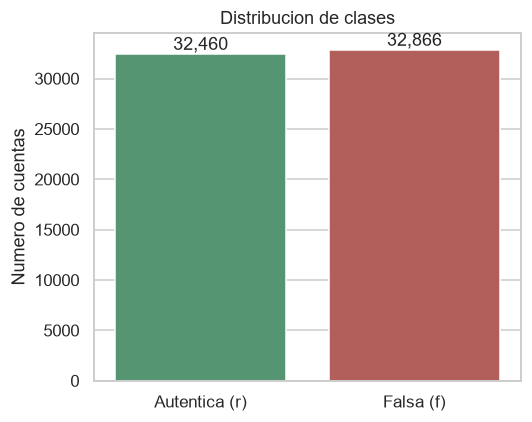

In [6]:
# 3.2 Distribucion de la variable objetivo
conteo = df['class'].value_counts()
prop = (conteo / len(df) * 100).round(2)
print(conteo.to_string())
print('\nPorcentaje:'); print(prop.to_string())

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(data=df, x='class', order=['r','f'], palette=['#4C9F70','#C0504D'], ax=ax)
ax.set_xticklabels(['Autentica (r)', 'Falsa (f)'])
ax.set_xlabel(''); ax.set_ylabel('Numero de cuentas')
ax.set_title('Distribucion de clases')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/01_distribucion_clases.png', bbox_inches='tight'); plt.show()

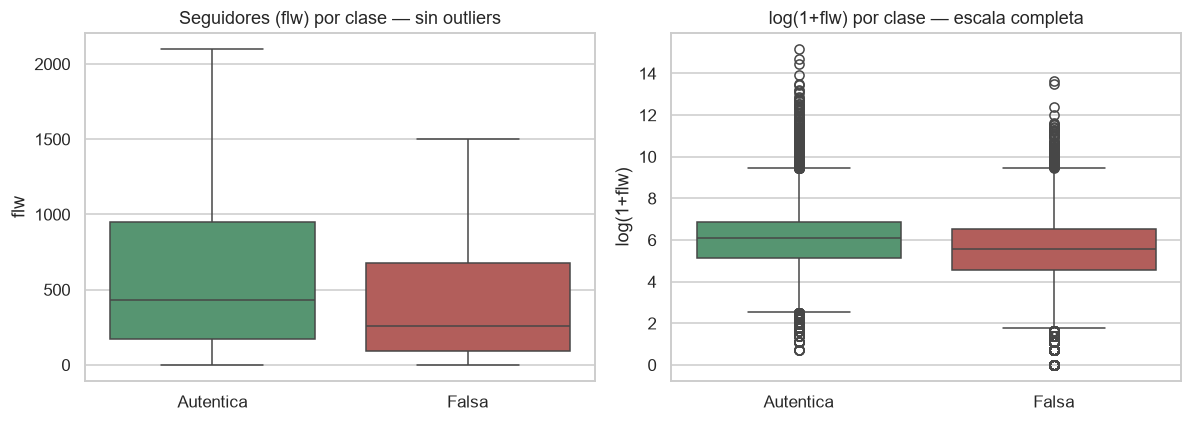

In [7]:
# 3.3 Distribucion de seguidores por clase (escala logaritmica por la fuerte asimetria)
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(data=df, x='class', y='flw', order=['r','f'],
            palette=['#4C9F70','#C0504D'], showfliers=False, ax=axes[0])
axes[0].set_title('Seguidores (flw) por clase — sin outliers')
axes[0].set_xticklabels(['Autentica','Falsa']); axes[0].set_xlabel(''); axes[0].set_ylabel('flw')

sns.boxplot(data=df.assign(log_flw=np.log1p(df['flw'])), x='class', y='log_flw', order=['r','f'],
            palette=['#4C9F70','#C0504D'], ax=axes[1])
axes[1].set_title('log(1+flw) por clase — escala completa')
axes[1].set_xticklabels(['Autentica','Falsa']); axes[1].set_xlabel(''); axes[1].set_ylabel('log(1+flw)')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/02_boxplot_flw.png', bbox_inches='tight'); plt.show()

In [8]:
# 3.4 Asimetria de las variables: justifica la transformacion logaritmica de la Seccion 4
asimetria = df.drop(columns='class').skew().sort_values(ascending=False).round(2)
print('Asimetria (skewness) por variable:')
print(asimetria.to_string())

Asimetria (skewness) por variable:
erl    167.80
flw    125.26
erc     96.32
fo      46.44
pos     33.20
pr      33.08
hc       8.72
pi       5.96
cl       3.01
ni       1.39
lt       1.32
cz       1.18
cs       1.11
flg      1.07
lin      0.97
bl       0.92
pic     -4.22


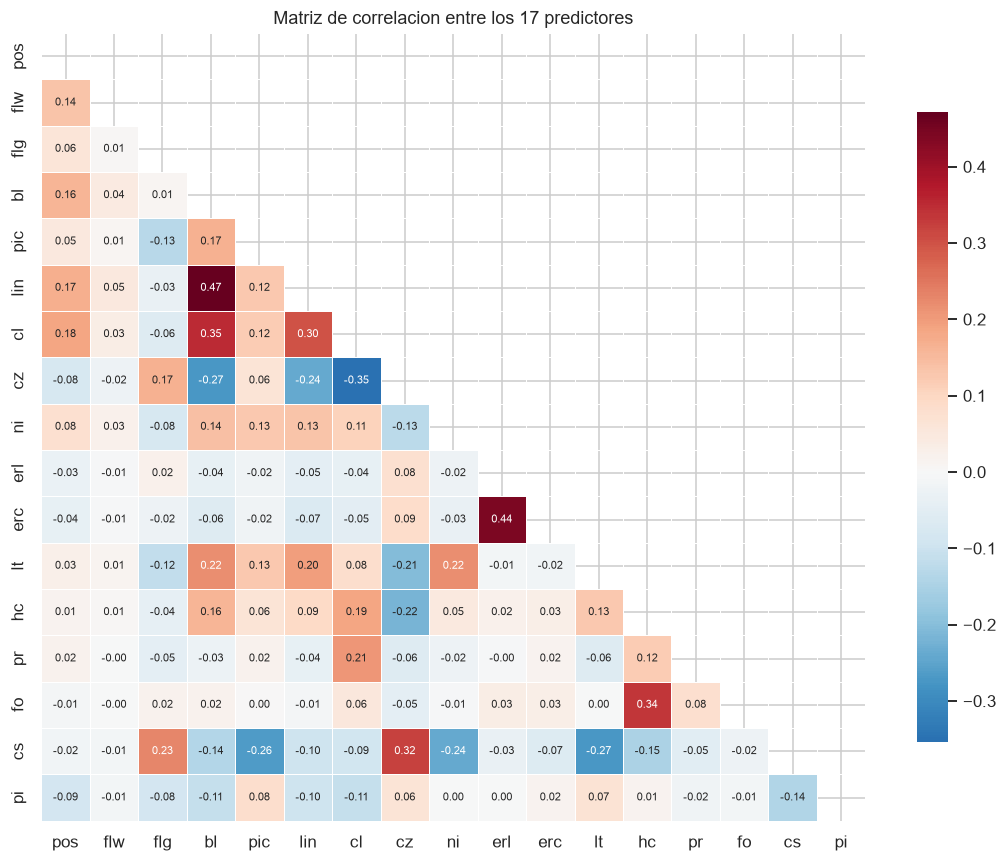


Pares con |r| > 0.5:
var_1 var_2  correlacion
  pos   pos          1.0
  flw   flw          1.0
  flg   flg          1.0
   bl    bl          1.0
  pic   pic          1.0
  lin   lin          1.0
   cl    cl          1.0
   cz    cz          1.0
   ni    ni          1.0
  erl   erl          1.0
  erc   erc          1.0
   lt    lt          1.0
   hc    hc          1.0
   pr    pr          1.0
   fo    fo          1.0
   cs    cs          1.0
   pi    pi          1.0


In [9]:
# 3.5 Matriz de correlacion entre predictores
corr = df.drop(columns='class').corr()
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size':7}, cbar_kws={'shrink':0.8}, linewidths=0.4, ax=ax)
ax.set_title('Matriz de correlacion entre los 17 predictores')
plt.tight_layout(); plt.savefig(f'{RUTA_FIGS}/03_correlacion.png', bbox_inches='tight'); plt.show()

# pares con correlacion alta (posible redundancia)
pares = corr.where(mask).stack().reset_index()
pares.columns = ['var_1','var_2','correlacion']
print('\nPares con |r| > 0.5:')
print(pares[pares.correlacion.abs() > 0.5].sort_values('correlacion', key=abs, ascending=False).to_string(index=False))

In [10]:
# 3.6 Comparacion de medias por clase: primera senal de que variables discriminan
comparacion = df.groupby('class').mean().T
comparacion.columns = ['Falsa (f)', 'Autentica (r)']
comparacion['diferencia_relativa'] = ((comparacion['Falsa (f)'] - comparacion['Autentica (r)']) /
                                      (comparacion['Autentica (r)'].abs() + 1e-9)).round(2)
display(comparacion.sort_values('diferencia_relativa', key=abs, ascending=False).round(3))

,Falsa (f),Autentica (r),diferencia_relativa
pr,0.056,0.010,4.80
flg,3330.622,1277.657,1.61
fo,0.073,0.033,1.23
cs,0.406,0.191,1.12
cz,0.319,0.181,0.76
lin,0.117,0.449,-0.74
lt,0.113,0.306,-0.63
flw,711.132,1660.926,-0.57
pi,350.165,644.616,-0.46
bl,41.301,73.895,-0.44


## 4. Limpieza y preprocesamiento

Tres decisiones, cada una documentada porque afectan a los cinco modelos por igual:

**4.1 Duplicados exactos.** Existen 1 082 filas repetidas, todas de la clase falsa y correspondientes a
perfiles prácticamente vacíos. Se conserva una ocurrencia de cada una y se eliminan las repeticiones:
si una misma fila quedara a la vez en entrenamiento y en prueba, las métricas estarían infladas por
fuga de información. El patrón "perfil vacío = cuenta falsa" se mantiene representado.

**4.2 Valores centinela.** La variable `cl` (longitud promedio del texto) tiene 162 registros con valor
`-1`, correspondientes a cuentas sin ninguna publicación. Se recodifican a `0`, que es su
interpretación real: no hay texto que medir.

**4.3 Codificación de la etiqueta.** `f` (falsa) → **1** y `r` (auténtica) → **0**. La clase falsa se define como
clase positiva porque, según el objetivo del proyecto, el costo de no detectar una cuenta falsa es
mayor que el de descartar por error una auténtica; recall y F1 se reportan sobre esa clase.

In [11]:
df_limpio = df.copy()

n_antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
print(f'Duplicados eliminados: {n_antes - len(df_limpio)}  ->  registros restantes: {len(df_limpio)}')

n_cl = int((df_limpio['cl'] < 0).sum())
df_limpio.loc[df_limpio['cl'] < 0, 'cl'] = 0
print(f'Valores centinela recodificados en cl: {n_cl}')

df_limpio['y'] = (df_limpio['class'] == 'f').astype(int)   # 1 = falsa, 0 = autentica
print('\nDistribucion final de clases (0=autentica, 1=falsa):')
print(df_limpio['y'].value_counts().sort_index().to_string())

Duplicados eliminados: 1082  ->  registros restantes: 64244
Valores centinela recodificados en cl: 1

Distribucion final de clases (0=autentica, 1=falsa):
y
0    32460
1    31784


## 5. Partición entrenamiento / prueba

Partición estratificada 80/20 con `random_state=42`. La estratificación preserva la proporción de
clases en ambos subconjuntos y la semilla fija garantiza que los cinco modelos —entrenados en
notebooks distintos por tres personas distintas— vean exactamente las mismas filas.

In [12]:
from sklearn.model_selection import train_test_split

VARIABLES = list(DICCIONARIO.keys())   # los 17 predictores, en orden fijo
X = df_limpio[VARIABLES]
y = df_limpio['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA
)

print(f'Entrenamiento: {X_train.shape[0]:,} registros')
print(f'Prueba:        {X_test.shape[0]:,} registros')
print(f'\nProporcion de clase falsa — train: {y_train.mean():.4f} | test: {y_test.mean():.4f}')

Entrenamiento: 51,395 registros
Prueba:        12,849 registros

Proporcion de clase falsa — train: 0.4947 | test: 0.4947


## 6. Transformación de variables

Se generan **dos versiones de la misma partición**, sin volver a dividir los datos:

- **Versión sin transformar** — para Árbol de Decisión, Random Forest y Gradient Boosting. Los modelos
  basados en árboles dividen por umbrales y son invariantes a cambios monótonos de escala; transformarlos
  no aporta nada y dificulta leer las reglas del árbol en unidades reales.
- **Versión transformada** — para Regresión Logística y MLP. Se aplica `log(1+x)` a las variables de
  conteo con asimetría extrema (`flw`, `erl`, `erc`, `pos`, `pi`, `fo`, `pr`, `cl`, `hc`, `flg`, `bl`) y luego
  estandarización z. Sin esto, un valor de 3 900 000 seguidores domina el gradiente y la regularización.

El `StandardScaler` y los parámetros de la transformación se ajustan **solo con el conjunto de
entrenamiento** y se aplican al de prueba, para no filtrar información del conjunto de prueba.

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

VARS_LOG = ['pos','flw','flg','bl','cl','erl','erc','hc','pr','fo','pi']  # asimetria alta
VARS_SIN_LOG = [v for v in VARIABLES if v not in VARS_LOG]
print('Variables con log(1+x):', VARS_LOG)
print('Variables sin transformar:', VARS_SIN_LOG)

def aplicar_log(X_df):
    Xt = X_df.copy()
    Xt[VARS_LOG] = np.log1p(Xt[VARS_LOG])
    return Xt

X_train_log = aplicar_log(X_train)
X_test_log  = aplicar_log(X_test)

escalador = StandardScaler().fit(X_train_log)                       # ajustado SOLO con train
X_train_esc = pd.DataFrame(escalador.transform(X_train_log), columns=VARIABLES, index=X_train.index)
X_test_esc  = pd.DataFrame(escalador.transform(X_test_log),  columns=VARIABLES, index=X_test.index)

print('\nVerificacion (train escalado): media ~0, desv ~1')
display(X_train_esc.describe().T[['mean','std','min','max']].round(3))

Variables con log(1+x): ['pos', 'flw', 'flg', 'bl', 'cl', 'erl', 'erc', 'hc', 'pr', 'fo', 'pi']
Variables sin transformar: ['pic', 'lin', 'cz', 'ni', 'lt', 'cs']

Verificacion (train escalado): media ~0, desv ~1


,mean,std,min,max
pos,-0.0,1.0,-1.783,4.040
flw,-0.0,1.0,-4.117,6.692
flg,0.0,1.0,-4.717,1.470
bl,0.0,1.0,-1.272,1.687
pic,-0.0,1.0,-4.827,0.207
lin,-0.0,1.0,-0.634,1.578
cl,0.0,1.0,-1.742,2.269
cz,-0.0,1.0,-0.748,2.197
ni,0.0,1.0,-0.775,3.164
erl,0.0,1.0,-1.820,5.270


## 7. Guardado de la partición compartida en Drive

In [14]:
np.savez_compressed(
    f'{RUTA_SPLIT}/particion.npz',
    X_train=X_train.values, X_test=X_test.values,
    X_train_esc=X_train_esc.values, X_test_esc=X_test_esc.values,
    y_train=y_train.values, y_test=y_test.values,
    variables=np.array(VARIABLES)
)
joblib.dump(escalador, f'{RUTA_SPLIT}/escalador.joblib')

metadatos = {
    'dataset': 'user_fake_authentic_2class.csv (Purba, Asirvatham & Murugesan, IJECE 2020)',
    'registros_originales': int(len(df)),
    'duplicados_eliminados': int(n_antes - len(df_limpio)),
    'registros_finales': int(len(df_limpio)),
    'variables': VARIABLES,
    'variables_log1p': VARS_LOG,
    'clase_positiva': 'f (cuenta falsa) = 1',
    'proporcion_test': 0.20,
    'estratificado': True,
    'random_state': SEMILLA,
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
}
with open(f'{RUTA_SPLIT}/metadatos.json', 'w', encoding='utf-8') as fh:
    json.dump(metadatos, fh, indent=2, ensure_ascii=False)

print('Archivos guardados en', RUTA_SPLIT)
print(os.listdir(RUTA_SPLIT))

Archivos guardados en C:/Users/JDC/Drive/Proyecto_IA_Grupo4/split
['escalador.joblib', 'metadatos.json', 'particion.npz']


## 8. Celda de carga para los demás notebooks

Cada integrante copia **esta celda** al inicio de su notebook. Nadie vuelve a leer el CSV ni a
particionar los datos: eso rompería la comparabilidad entre los cinco modelos.

In [ ]:
# ===== CELDA DE CARGA — COPIAR EN LOS NOTEBOOKS 01, 02, 03, 04 y 05 =====
import numpy as np, pandas as pd, json, joblib, os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA = '/content/drive/MyDrive/Proyecto_IA_Grupo4'
except Exception:
    # Ejecutando localmente: ajuste esta ruta a la carpeta compartida del grupo
    CARPETA = os.path.expanduser(r'c:/Users/JDC/Universidad/File_General/NIVEL_400-I/Proy_IA_G4')
RUTA_SPLIT = f'{CARPETA}/split'

datos = np.load(f'{RUTA_SPLIT}/particion.npz', allow_pickle=True)
VARIABLES = list(datos['variables'])

X_train      = pd.DataFrame(datos['X_train'],     columns=VARIABLES)   # arboles y ensambles
X_test       = pd.DataFrame(datos['X_test'],      columns=VARIABLES)
X_train_esc  = pd.DataFrame(datos['X_train_esc'], columns=VARIABLES)   # regresion logistica y MLP
X_test_esc   = pd.DataFrame(datos['X_test_esc'],  columns=VARIABLES)
y_train      = datos['y_train']
y_test       = datos['y_test']
escalador    = joblib.load(f'{RUTA_SPLIT}/escalador.joblib')

print('Train:', X_train.shape, '| Test:', X_test.shape,
      '| Clase falsa en train:', round(y_train.mean(), 4))

---
### Resumen de lo que queda fijo para todo el equipo

- 17 predictores en orden fijo (`VARIABLES`), sin variables derivadas añadidas.
- Clase positiva: cuenta falsa (`1`).
- Partición estratificada 80/20 con `random_state=42`, generada una sola vez.
- Dos versiones de la misma partición: sin escalar (árboles) y escalada (regresión logística, MLP).
- Métrica principal de selección: **F1 sobre la clase falsa**; se reportan además precisión, recall,
  AUC-ROC y matriz de confusión.
- Cada modelo debe entregar, además de sus métricas, su explicación de variables (coeficientes,
  importancias o SHAP), porque ningún modelo del proyecto puede quedar como caja negra.